# Cluster Analysis – B2B Customer Segmentation

This notebook applies three clustering approaches to the preprocessed company dataset:
1. **K-Means** (with Elbow + Silhouette for optimal k)
2. **Hierarchical Clustering** (single, complete, average, ward, centroid linkage)
3. **HDBSCAN** (density-based, automatic cluster detection)

Finally, all methods are compared side by side.

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import hdbscan

In [192]:
df_companies_scaled = pd.read_csv('data/df_final.csv', index_col='customer_id')
df_companies_scaled = df_companies_scaled[df_companies_scaled.index != 153]
feature_matrix = df_companies_scaled.values

print(f'Dataset: {df_companies_scaled.shape[0]} companies, {df_companies_scaled.shape[1]} features')
df_companies_scaled.head()

Dataset: 547 companies, 20 features


,Recency,Frequency,Monetary Value,Regale,Lager Zubehör,Sonstige Produkte,Werkstätte_gesamt,Garderoben_gesamt,industry_group_ZG 1+2,industry_group_ZG 3+4,industry_group_ZG 5+6,industry_group_ZG 7,industry_group_ZG 8,industry_group_ZG 9,bundesland_Ost,bundesland_Süd,bundesland_West,company_size_Groß,company_size_Klein,company_size_Mittel
customer_id,,,,,,,,,,,,,,,,,,,,
0,-1.213131,0.001001,-0.059224,0.483673,-0.192680,-0.337673,-0.052175,-0.237917,1.973032,-0.334009,-0.313363,-0.905869,-0.306288,-0.272965,-1.85884,-0.392026,3.155947,2.591970,-1.025882,-0.746203
1,1.710647,-0.163568,-0.238288,-0.311759,-0.192680,-0.337673,-0.087135,-0.234709,-0.506834,-0.334009,-0.313363,1.103913,-0.306288,-0.272965,0.53797,-0.392026,-0.316862,-0.385807,0.974771,-0.746203
2,-1.179936,0.001001,-0.156837,-0.267269,-0.192680,-0.335407,-0.009088,-0.199838,1.973032,-0.334009,-0.313363,-0.905869,-0.306288,-0.272965,0.53797,-0.392026,-0.316862,-0.385807,-1.025882,1.340119
3,-0.182771,0.001001,0.428650,1.131445,0.549909,1.017620,0.167330,0.009574,-0.506834,-0.334009,-0.313363,1.103913,-0.306288,-0.272965,0.53797,-0.392026,-0.316862,2.591970,-1.025882,-0.746203
5,-1.307403,-0.053855,-0.123823,-0.311759,-0.192680,-0.120870,-0.087135,0.035233,-0.506834,-0.334009,-0.313363,-0.905869,-0.306288,3.663475,-1.85884,2.550853,-0.316862,-0.385807,-1.025882,1.340119


## 1. K-Means Clustering

### 1.1 Determine optimal number of clusters k

- **Elbow Method**: Plot inertia (within-cluster sum of squares) for k = 2 .. 15. Look for the "elbow" where adding more clusters stops reducing inertia significantly.
- **Silhouette Score**: Higher is better (range -1 to 1). Measures how similar each point is to its own cluster vs. neighbouring clusters.

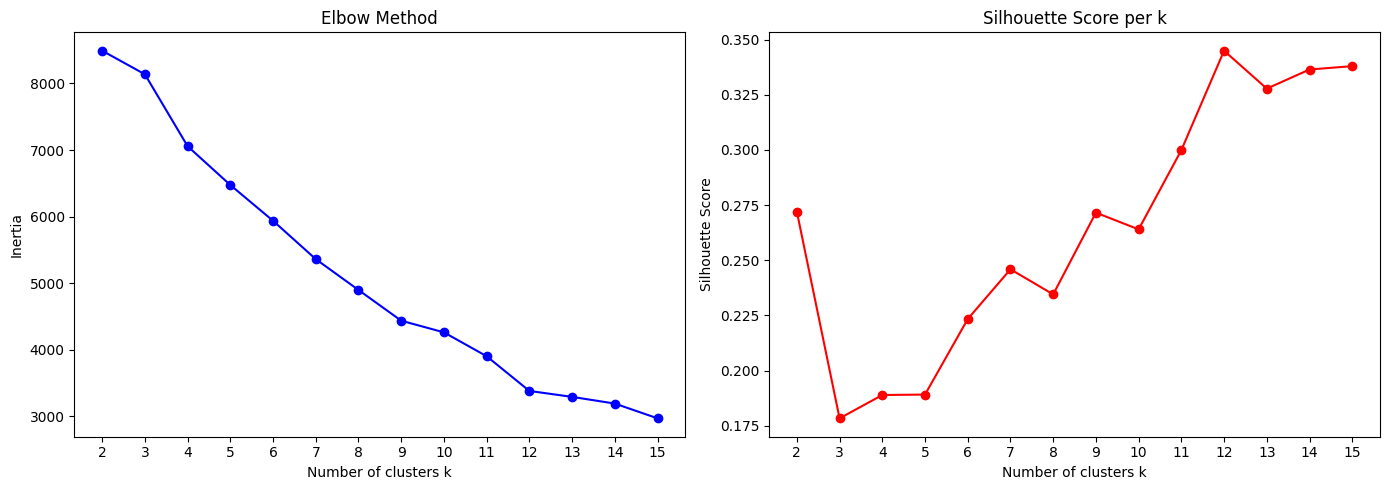

k= 2  |  Inertia:     8492.1  |  Silhouette: 0.2720
k= 3  |  Inertia:     8137.8  |  Silhouette: 0.1783
k= 4  |  Inertia:     7057.1  |  Silhouette: 0.1889
k= 5  |  Inertia:     6474.5  |  Silhouette: 0.1891
k= 6  |  Inertia:     5936.9  |  Silhouette: 0.2233
k= 7  |  Inertia:     5361.0  |  Silhouette: 0.2459
k= 8  |  Inertia:     4897.7  |  Silhouette: 0.2345
k= 9  |  Inertia:     4436.1  |  Silhouette: 0.2716
k=10  |  Inertia:     4260.9  |  Silhouette: 0.2640
k=11  |  Inertia:     3902.2  |  Silhouette: 0.2999
k=12  |  Inertia:     3380.9  |  Silhouette: 0.3450
k=13  |  Inertia:     3291.6  |  Silhouette: 0.3278
k=14  |  Inertia:     3191.3  |  Silhouette: 0.3365
k=15  |  Inertia:     2969.3  |  Silhouette: 0.3380


In [193]:
k_range = range(2, 16)
kmeans_inertia_per_k = []
kmeans_silhouette_per_k = []

for k in k_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans_model.fit_predict(feature_matrix)
    kmeans_inertia_per_k.append(kmeans_model.inertia_)
    kmeans_silhouette_per_k.append(silhouette_score(feature_matrix, labels))

# Plot both metrics side by side
fig, (ax_elbow, ax_silhouette) = plt.subplots(1, 2, figsize=(14, 5))

ax_elbow.plot(k_range, kmeans_inertia_per_k, 'bo-')
ax_elbow.set_xlabel('Number of clusters k')
ax_elbow.set_ylabel('Inertia')
ax_elbow.set_title('Elbow Method')
ax_elbow.set_xticks(list(k_range))

ax_silhouette.plot(k_range, kmeans_silhouette_per_k, 'ro-')
ax_silhouette.set_xlabel('Number of clusters k')
ax_silhouette.set_ylabel('Silhouette Score')
ax_silhouette.set_title('Silhouette Score per k')
ax_silhouette.set_xticks(list(k_range))

plt.tight_layout()
plt.show()

# Print scores for reference
for k, inertia, sil in zip(k_range, kmeans_inertia_per_k, kmeans_silhouette_per_k):
    print(f'k={k:2d}  |  Inertia: {inertia:10.1f}  |  Silhouette: {sil:.4f}')

### 1.2 Fit K-Means with chosen k

Set `optimal_k_kmeans` below based on the Elbow and Silhouette plots above.

In [194]:
# --- Set the optimal k here based on the plots above ---
optimal_k_kmeans = 10

kmeans_model = KMeans(n_clusters=optimal_k_kmeans, random_state=42, n_init='auto')
kmeans_cluster_labels = kmeans_model.fit_predict(feature_matrix)

# Evaluation
kmeans_silhouette = silhouette_score(feature_matrix, kmeans_cluster_labels)
kmeans_davies_bouldin = davies_bouldin_score(feature_matrix, kmeans_cluster_labels)

print(f'K-Means (k={optimal_k_kmeans})')
print(f'  Silhouette Score:     {kmeans_silhouette:.4f}')
print(f'  Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}')
print(f'\nCluster sizes:')
print(pd.Series(kmeans_cluster_labels).value_counts().sort_index().to_string())

K-Means (k=10)
  Silhouette Score:     0.2640
  Davies-Bouldin Index: 1.4675

Cluster sizes:
0     49
1     76
2     48
3     46
4     58
5     45
6    163
7      8
8     50
9      4


## 2. Hierarchical Clustering

### 2.1 Dendrogram (Ward Linkage)

Ward linkage minimises within-cluster variance and is recommended for standardised data.
Two views: overview (last 30 merges) and detail (first 5 levels).

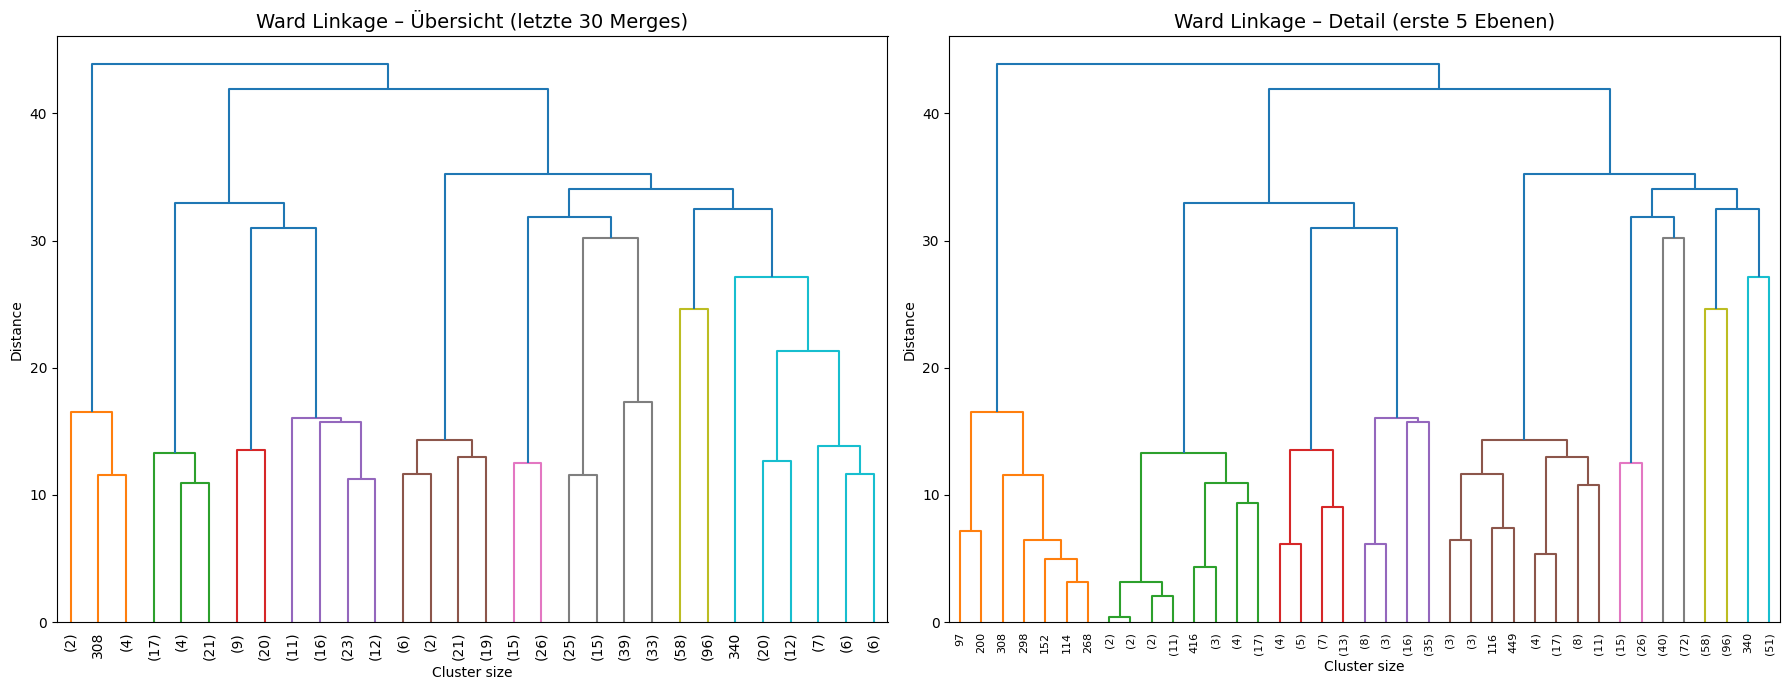

In [195]:
# Compute linkage matrix
ward_linkage = linkage(feature_matrix, method='ward')

# Plot two dendrogram views
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Overview: last 30 merges
dendrogram(
    ward_linkage,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    ax=axes[0]
)
axes[0].set_title('Ward Linkage – Übersicht (letzte 30 Merges)', fontsize=14)
axes[0].set_xlabel('Cluster size')
axes[0].set_ylabel('Distance')

# Detail: first 5 levels
dendrogram(
    ward_linkage,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    ax=axes[1]
)
axes[1].set_title('Ward Linkage – Detail (erste 5 Ebenen)', fontsize=14)
axes[1].set_xlabel('Cluster size')
axes[1].set_ylabel('Distance')

plt.tight_layout()
plt.show()

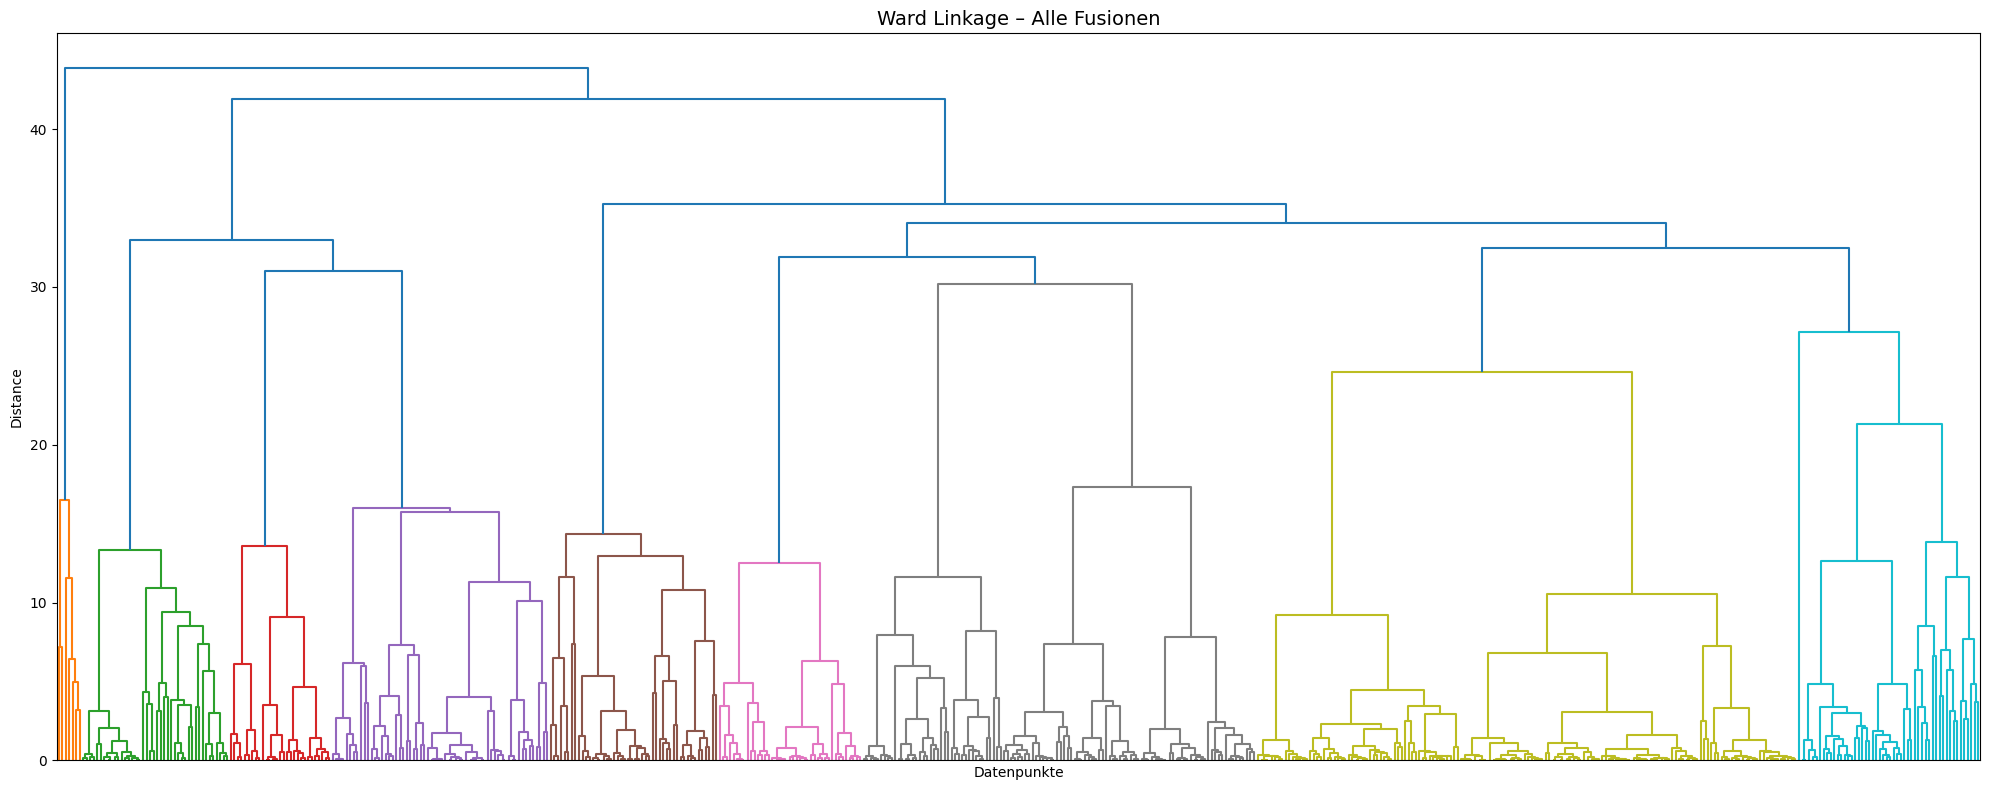

In [196]:
# Full dendrogram (all fusions)
plt.figure(figsize=(20, 8))
dendrogram(
    ward_linkage,
    no_labels=True,
    leaf_rotation=90
)
plt.title('Ward Linkage – Alle Fusionen', fontsize=14)
plt.xlabel('Datenpunkte')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [197]:
k_range = range(2, 20)

silhouette_scores_ward = []
davies_bouldin_scores_ward = []

for k in k_range:
    labels = fcluster(ward_linkage, t=k, criterion='maxclust')
    silhouette_scores_ward.append(silhouette_score(feature_matrix, labels))
    davies_bouldin_scores_ward.append(davies_bouldin_score(feature_matrix, labels))

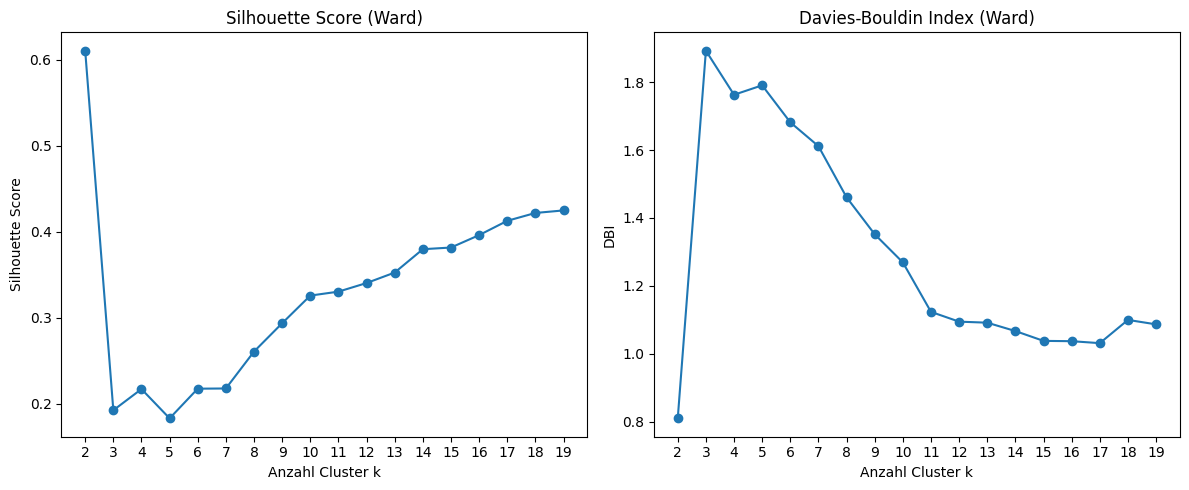

In [198]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, silhouette_scores_ward, marker='o')
plt.title('Silhouette Score (Ward)')
plt.xlabel('Anzahl Cluster k')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)

plt.subplot(1, 2, 2)
plt.plot(k_range, davies_bouldin_scores_ward, marker='o')
plt.title('Davies-Bouldin Index (Ward)')
plt.xlabel('Anzahl Cluster k')
plt.ylabel('DBI')
plt.xticks(k_range)

plt.tight_layout()
plt.show()

### 2.2 Cut dendrograms and evaluate

Set `optimal_k_hierarchical` below based on the dendrograms above.

In [199]:
# --- Set the optimal k here based on the dendrograms above ---
optimal_k_hierarchical = 12

hierarchical_cluster_labels = fcluster(ward_linkage, t=optimal_k_hierarchical, criterion='maxclust')

hierarchical_sil = silhouette_score(feature_matrix, hierarchical_cluster_labels)
hierarchical_dbi = davies_bouldin_score(feature_matrix, hierarchical_cluster_labels)
cluster_sizes = pd.Series(hierarchical_cluster_labels).value_counts().sort_index().to_dict()

print(f'{"Ward":10s}  |  Silhouette: {hierarchical_sil:.4f}  |  Davies-Bouldin: {hierarchical_dbi:.4f}  |  Sizes: {cluster_sizes}')

Ward        |  Silhouette: 0.3404  |  Davies-Bouldin: 1.0946  |  Sizes: {1: 7, 2: 42, 3: 29, 4: 62, 5: 48, 6: 41, 7: 40, 8: 72, 9: 58, 10: 96, 11: 51, 12: 1}


## 3. DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) findet Cluster basierend auf der Dichte der Datenpunkte.  
Zwei wichtige Parameter:
- **eps**: maximaler Abstand zwischen zwei Punkten im selben Cluster
- **min_samples**: minimale Anzahl Punkte in einer Nachbarschaft, damit ein Punkt als "Core Point" gilt

Punkte, die keinem Cluster zugeordnet werden, sind **Noise** (Label = -1).

### 3.1 Optimalen eps-Wert finden (k-Distance Plot)

Man berechnet für jeden Punkt den Abstand zum k-nächsten Nachbarn (k = min_samples) und sortiert diese Abstände.  
Der "Knick" im Plot zeigt einen guten eps-Wert.

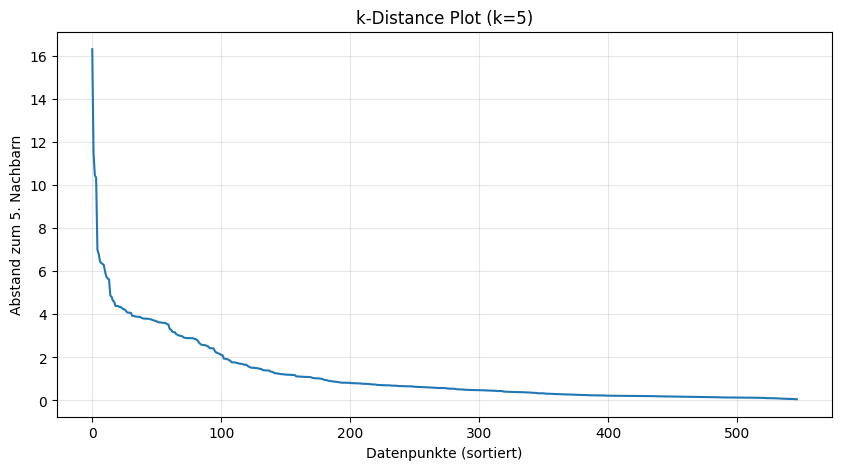

  90% der Punkte haben k-distance ≤ 0.140
  85% der Punkte haben k-distance ≤ 0.170
  80% der Punkte haben k-distance ≤ 0.198
  75% der Punkte haben k-distance ≤ 0.217
  70% der Punkte haben k-distance ≤ 0.254


In [200]:
# --- k-Distance Plot zur eps-Bestimmung ---
min_samples_dbscan = 5

# Berechne den Abstand zum k-nächsten Nachbarn für jeden Punkt
neighbors = NearestNeighbors(n_neighbors=min_samples_dbscan)
neighbors.fit(feature_matrix)
distances, _ = neighbors.kneighbors(feature_matrix)

# Sortiere die Abstände zum k-ten Nachbarn (letzte Spalte)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel('Datenpunkte (sortiert)')
plt.ylabel(f'Abstand zum {min_samples_dbscan}. Nachbarn')
plt.title(f'k-Distance Plot (k={min_samples_dbscan})')
plt.grid(True, alpha=0.3)
plt.show()

# Hilfe: zeige einige Quantile, um eps-Wert einzugrenzen
for q in [0.90, 0.85, 0.80, 0.75, 0.70]:
    val = np.quantile(k_distances, 1 - q)
    print(f'  {q:.0%} der Punkte haben k-distance ≤ {val:.3f}')

### 3.2 DBSCAN ausführen

Setze `eps_dbscan` basierend auf dem k-Distance Plot oben (dort wo der Knick ist).

In [201]:
# --- DBSCAN Clustering ---
# eps und min_samples hier anpassen:
eps_dbscan = 3.7
min_samples_dbscan = 5

dbscan_model = DBSCAN(eps=eps_dbscan, min_samples=min_samples_dbscan)
dbscan_cluster_labels = dbscan_model.fit_predict(feature_matrix)

# Ergebnisse zusammenfassen
n_clusters_dbscan = len(set(dbscan_cluster_labels)) - (1 if -1 in dbscan_cluster_labels else 0)
n_noise_dbscan = (dbscan_cluster_labels == -1).sum()
noise_ratio_dbscan = n_noise_dbscan / len(dbscan_cluster_labels)

print(f'DBSCAN (eps={eps_dbscan}, min_samples={min_samples_dbscan})')
print(f'  Gefundene Cluster: {n_clusters_dbscan}')
print(f'  Noise-Punkte:      {n_noise_dbscan} ({noise_ratio_dbscan:.1%})')

# Metriken berechnen (nur möglich wenn min. 2 Cluster und nicht alles Noise)
if n_clusters_dbscan >= 2:
    non_noise_mask_dbscan = dbscan_cluster_labels != -1
    dbscan_silhouette = silhouette_score(
        feature_matrix[non_noise_mask_dbscan], dbscan_cluster_labels[non_noise_mask_dbscan]
    )
    dbscan_davies_bouldin = davies_bouldin_score(
        feature_matrix[non_noise_mask_dbscan], dbscan_cluster_labels[non_noise_mask_dbscan]
    )
    print(f'  Silhouette Score:     {dbscan_silhouette:.4f} (ohne Noise)')
    print(f'  Davies-Bouldin Index: {dbscan_davies_bouldin:.4f} (ohne Noise)')
else:
    dbscan_silhouette = np.nan
    dbscan_davies_bouldin = np.nan
    print('  Nicht genug Cluster für Metriken.')

print(f'\nCluster-Größen (Label -1 = Noise):')
print(pd.Series(dbscan_cluster_labels).value_counts().sort_index().to_string())

DBSCAN (eps=3.7, min_samples=5)
  Gefundene Cluster: 10
  Noise-Punkte:      34 (6.2%)
  Silhouette Score:     0.3591 (ohne Noise)
  Davies-Bouldin Index: 1.1459 (ohne Noise)

Cluster-Größen (Label -1 = Noise):
-1     34
 0    269
 1      9
 2     37
 3     23
 4     42
 5     39
 6     46
 7     32
 8     10
 9      6


## 4. HDBSCAN

HDBSCAN automatically determines the number of clusters based on density.
Points that don't belong to any dense region are labeled as **noise** (label = -1).

In [202]:

# default min_cluster_size = 10, min_samples = 5
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=4)
hdbscan_cluster_labels = hdbscan_model.fit_predict(feature_matrix)

n_clusters_hdbscan = len(set(hdbscan_cluster_labels)) - (1 if -1 in hdbscan_cluster_labels else 0)
n_noise_points = (hdbscan_cluster_labels == -1).sum()
noise_ratio_hdbscan = n_noise_points / len(hdbscan_cluster_labels)

print(f'HDBSCAN')
print(f'  Clusters found: {n_clusters_hdbscan}')
print(f'  Noise points:   {n_noise_points} ({noise_ratio_hdbscan:.1%})')

# Metrics only possible with at least 2 clusters (excluding noise)
if n_clusters_hdbscan >= 2:
    non_noise_mask = hdbscan_cluster_labels != -1
    hdbscan_silhouette = silhouette_score(
        feature_matrix[non_noise_mask], hdbscan_cluster_labels[non_noise_mask]
    )
    hdbscan_davies_bouldin = davies_bouldin_score(
        feature_matrix[non_noise_mask], hdbscan_cluster_labels[non_noise_mask]
    )
    print(f'  Silhouette Score:     {hdbscan_silhouette:.4f} (noise excluded)')
    print(f'  Davies-Bouldin Index: {hdbscan_davies_bouldin:.4f} (noise excluded)')
else:
    hdbscan_silhouette = np.nan
    hdbscan_davies_bouldin = np.nan
    print('  Not enough clusters for evaluation metrics.')

print(f'\nCluster sizes (label -1 = noise):')
print(pd.Series(hdbscan_cluster_labels).value_counts().sort_index().to_string())

HDBSCAN
  Clusters found: 11
  Noise points:   34 (6.2%)
  Silhouette Score:     0.4184 (noise excluded)
  Davies-Bouldin Index: 0.9144 (noise excluded)

Cluster sizes (label -1 = noise):
-1     34
 0     33
 1     41
 2     45
 3     39
 4     47
 5     46
 6     37
 7     33
 8     39
 9     95
 10    58


## 5. Comparison of Clustering Methods

### 5.1 Metrics Table

| Metric | Meaning | Better |
|--------|---------|--------|
| Silhouette Score | Cluster cohesion vs. separation (-1 to 1) | Higher |
| Davies-Bouldin Index | Average similarity between clusters (≥ 0) | Lower |

In [203]:
comparison_rows = []

# K-Means
comparison_rows.append({
    'Method': f'K-Means (k={optimal_k_kmeans})',
    'Clusters': optimal_k_kmeans,
    'Silhouette': round(kmeans_silhouette, 4),
    'Davies-Bouldin': round(kmeans_davies_bouldin, 4),
    'Noise Ratio': '0.0%'
})

# Hierarchical (Ward)
comparison_rows.append({
    'Method': f'Ward (k = {optimal_k_hierarchical})',
    'Clusters': optimal_k_hierarchical,
    'Silhouette': round(hierarchical_sil, 4),
    'Davies-Bouldin': round(hierarchical_dbi, 4),
    'Noise Ratio': '0.0%'
})

# DBSCAN
comparison_rows.append({
    'Method': f'DBSCAN (eps={eps_dbscan})',
    'Clusters': n_clusters_dbscan,
    'Silhouette': round(dbscan_silhouette, 4) if not np.isnan(dbscan_silhouette) else 'N/A',
    'Davies-Bouldin': round(dbscan_davies_bouldin, 4) if not np.isnan(dbscan_davies_bouldin) else 'N/A',
    'Noise Ratio': f'{noise_ratio_dbscan:.1%}'
})

# HDBSCAN
comparison_rows.append({
    'Method': 'HDBSCAN',
    'Clusters': n_clusters_hdbscan,
    'Silhouette': round(hdbscan_silhouette, 4) if not np.isnan(hdbscan_silhouette) else 'N/A',
    'Davies-Bouldin': round(hdbscan_davies_bouldin, 4) if not np.isnan(hdbscan_davies_bouldin) else 'N/A',
    'Noise Ratio': f'{noise_ratio_hdbscan:.1%}'
})

df_comparison = pd.DataFrame(comparison_rows).set_index('Method')
df_comparison

,Clusters,Silhouette,Davies-Bouldin,Noise Ratio
Method,,,,
K-Means (k=10),10,0.2640,1.4675,0.0%
Ward (k = 12),12,0.3404,1.0946,0.0%
DBSCAN (eps=3.7),10,0.3591,1.1459,6.2%
HDBSCAN,11,0.4184,0.9144,6.2%


### 5.2 PCA Visualization

All clustering results projected onto the first two principal components for visual comparison.

PCA explained variance: PC1=18.8%, PC2=10.9%, total=29.7%


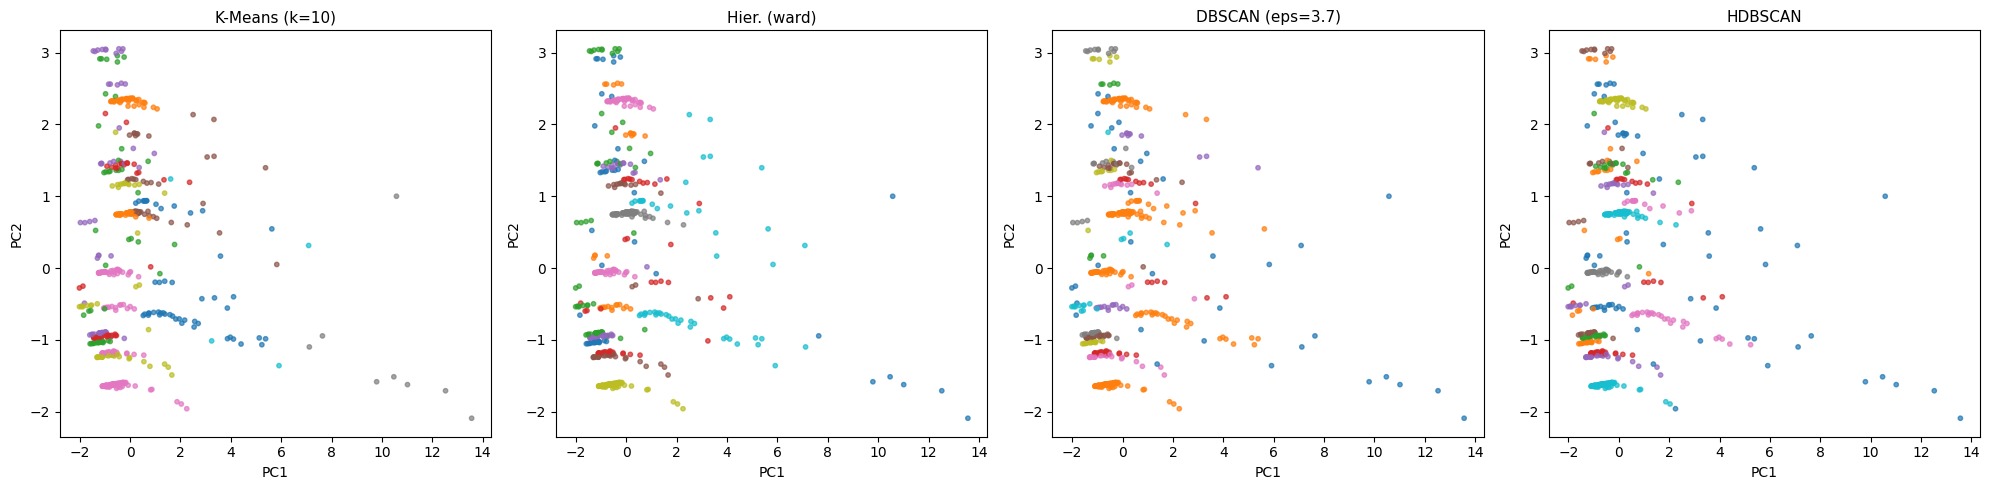

In [204]:
# Reduce to 2D for plotting
pca = PCA(n_components=2)
pca_coordinates = pca.fit_transform(feature_matrix)

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}, total={sum(pca.explained_variance_ratio_[:2]):.1%}')

# Collect all clustering results for plotting
all_cluster_label_sets = {
    f'K-Means (k={optimal_k_kmeans})': kmeans_cluster_labels,
}

all_cluster_label_sets['Hier. (ward)'] = hierarchical_cluster_labels
all_cluster_label_sets[f'DBSCAN (eps={eps_dbscan})'] = dbscan_cluster_labels
all_cluster_label_sets['HDBSCAN'] = hdbscan_cluster_labels

# Plot all methods in a grid
n_methods = len(all_cluster_label_sets)
n_cols = 4
n_rows = (n_methods + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, (method_name, labels) in enumerate(all_cluster_label_sets.items()):
    scatter = axes[i].scatter(
        pca_coordinates[:, 0], pca_coordinates[:, 1],
        c=labels, cmap='tab10', s=10, alpha=0.7
    )
    axes[i].set_title(method_name, fontsize=11)
    axes[i].set_xlabel('PC1')
    axes[i].set_ylabel('PC2')

# Hide unused subplots
for j in range(n_methods, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Excel-Export: Cluster-Zuordnung pro Methode

Für jede Clustering-Methode wird eine Excel-Datei im Ordner `Results/Companies/` erstellt, in der alle Firmen ihrem jeweiligen Cluster zugeordnet sind. Zusätzlich werden Medoids und Durchschnitte exportiert.

In [205]:
import os
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.metrics import silhouette_samples
import matplotlib.colors as mcolors
from scipy.spatial.distance import cdist

# Load company name mapping
df_name_mapping = pd.read_csv('data/customer_id_mapping.csv', index_col=0)
customer_id_to_name = df_name_mapping['company_name'].to_dict()

os.makedirs('Results/Companies', exist_ok=True)

index_ids = df_companies_scaled.index.tolist()

# Convert tab10 colormap to hex
tab10_cmap = plt.cm.tab10
def label_to_hex(label):
    if label == -1:
        return 'C0C0C0'
    rgba = tab10_cmap(label % 10)
    return mcolors.rgb2hex(rgba[:3]).replace('#', '')

def label_to_font_color(label):
    if label == -1:
        return '000000'
    rgba = tab10_cmap(label % 10)
    brightness = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    return 'FFFFFF' if brightness < 0.5 else '000000'

def compute_per_cluster_silhouette(X, labels):
    sample_sil = silhouette_samples(X, labels)
    unique_labels = sorted(set(labels))
    return {lbl: float(np.mean(sample_sil[labels == lbl])) for lbl in unique_labels}

def export_company_cluster_excel(filename, method_name, labels, feature_data, index_ids, df_with_columns):
    labels = np.array(labels)
    feature_columns = df_with_columns.columns.tolist()
    unique_labels = sorted(set(labels))
    has_noise = -1 in unique_labels

    non_noise_labels = [l for l in unique_labels if l != -1]
    if len(non_noise_labels) >= 2:
        if has_noise:
            mask = labels != -1
            per_cluster_sil = compute_per_cluster_silhouette(feature_data[mask], labels[mask])
        else:
            per_cluster_sil = compute_per_cluster_silhouette(feature_data, labels)
    else:
        per_cluster_sil = {l: np.nan for l in unique_labels}

    wb = Workbook()
    thin_border = Border(
        left=Side(style='thin'), right=Side(style='thin'),
        top=Side(style='thin'), bottom=Side(style='thin')
    )

    # --- Summary sheet ---
    ws_summary = wb.active
    ws_summary.title = '\u00dcbersicht'

    headers = ['Cluster', 'Anzahl Firmen', 'Silhouette Score']
    for col, h in enumerate(headers, 1):
        cell = ws_summary.cell(row=1, column=col, value=h)
        cell.font = Font(bold=True, size=12)
        cell.border = thin_border
        cell.alignment = Alignment(horizontal='center')

    for row_idx, lbl in enumerate(unique_labels, 2):
        cluster_name = 'Noise (kein Cluster)' if lbl == -1 else f'Cluster {lbl}'
        count = int(np.sum(labels == lbl))
        sil_val = per_cluster_sil.get(lbl, np.nan)

        bg_hex = label_to_hex(lbl)
        fg_hex = label_to_font_color(lbl)
        fill = PatternFill(start_color=bg_hex, end_color=bg_hex, fill_type='solid')
        font = Font(color=fg_hex, size=11)

        for col, val in enumerate([cluster_name, count, round(sil_val, 4) if not np.isnan(sil_val) else 'N/A'], 1):
            cell = ws_summary.cell(row=row_idx, column=col, value=val)
            cell.fill = fill
            cell.font = font
            cell.border = thin_border
            cell.alignment = Alignment(horizontal='center')

    for col in range(1, 4):
        ws_summary.column_dimensions[get_column_letter(col)].width = 26

    # --- One sheet per cluster ---
    for lbl in unique_labels:
        sheet_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ws = wb.create_sheet(title=sheet_name)

        bg_hex = label_to_hex(lbl)
        fg_hex = label_to_font_color(lbl)
        fill = PatternFill(start_color=bg_hex, end_color=bg_hex, fill_type='solid')
        font_colored = Font(color=fg_hex, size=11)

        sil_val = per_cluster_sil.get(lbl, np.nan)

        header_texts = ['#', 'Customer ID', 'Firmenname', 'Cluster', 'Silhouette Score (Cluster)']
        for col, h in enumerate(header_texts, 1):
            cell = ws.cell(row=1, column=col, value=h)
            cell.font = Font(bold=True, size=12)
            cell.border = thin_border
            cell.alignment = Alignment(horizontal='center')

        cluster_mask = labels == lbl
        cluster_ids = np.array(index_ids)[cluster_mask]

        for row_i, cid in enumerate(cluster_ids, 2):
            company_name = customer_id_to_name.get(cid, f'ID {cid}')
            cluster_display = 'Noise' if lbl == -1 else lbl
            sil_display = round(sil_val, 4) if not np.isnan(sil_val) else 'N/A'

            for col, val in enumerate([row_i - 1, cid, company_name, cluster_display, sil_display], 1):
                cell = ws.cell(row=row_i, column=col, value=val)
                cell.fill = fill
                cell.font = font_colored
                cell.border = thin_border
                if col != 3:
                    cell.alignment = Alignment(horizontal='center')

        ws.column_dimensions['A'].width = 6
        ws.column_dimensions['B'].width = 14
        ws.column_dimensions['C'].width = 50
        ws.column_dimensions['D'].width = 12
        ws.column_dimensions['E'].width = 26

    # --- Median sheet ---
    ws_median = wb.create_sheet(title='Cluster-Mediane')

    median_headers = ['Cluster', 'Medoid ID', 'Medoid Firmenname'] + feature_columns
    for col, h in enumerate(median_headers, 1):
        cell = ws_median.cell(row=1, column=col, value=h)
        cell.font = Font(bold=True, size=11)
        cell.border = thin_border
        cell.alignment = Alignment(horizontal='center')

    for row_idx, lbl in enumerate(unique_labels, 2):
        cluster_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        cluster_mask = labels == lbl
        cluster_data = feature_data[cluster_mask]
        cluster_ids = np.array(index_ids)[cluster_mask]
        median_values = np.median(cluster_data, axis=0)

        distances = cdist([median_values], cluster_data, metric='euclidean')[0]
        closest_idx = np.argmin(distances)
        medoid_id = cluster_ids[closest_idx]
        medoid_name = customer_id_to_name.get(medoid_id, f'ID {medoid_id}')

        bg_hex = label_to_hex(lbl)
        fg_hex = label_to_font_color(lbl)
        fill = PatternFill(start_color=bg_hex, end_color=bg_hex, fill_type='solid')
        font_colored = Font(color=fg_hex, size=11)

        row_vals = [cluster_name, medoid_id, medoid_name] + [round(float(v), 4) for v in median_values]
        for col_idx, val in enumerate(row_vals, 1):
            cell = ws_median.cell(row=row_idx, column=col_idx, value=val)
            cell.fill = fill
            cell.font = font_colored
            cell.border = thin_border
            if col_idx != 3:
                cell.alignment = Alignment(horizontal='center')

    ws_median.column_dimensions['A'].width = 16
    ws_median.column_dimensions['B'].width = 12
    ws_median.column_dimensions['C'].width = 50
    for col_idx in range(4, len(median_headers) + 1):
        ws_median.column_dimensions[get_column_letter(col_idx)].width = max(14, len(median_headers[col_idx - 1]) + 2)

    filepath = os.path.join('Results', 'Companies', filename)
    wb.save(filepath)
    print(f'  Saved: {filepath} ({len(unique_labels)} cluster sheets + Median sheet)')
    return per_cluster_sil

# Alle Clustering-Ergebnisse sammeln
all_clustering_labels = {
    f'K-Means (k={optimal_k_kmeans})': kmeans_cluster_labels,
    'Hierarchical (ward)': hierarchical_cluster_labels,
    f'DBSCAN (eps={eps_dbscan})': dbscan_cluster_labels,
    'HDBSCAN': hdbscan_cluster_labels,
}

print('=== Excel-Export: Firmen pro Cluster ===\n')

kmeans_per_cluster_sil = export_company_cluster_excel(
    'KMeans_Cluster.xlsx', 'K-Means', kmeans_cluster_labels, feature_matrix, index_ids, df_companies_scaled
)

export_company_cluster_excel(
    'Hierarchical_ward_Cluster.xlsx', 'Hier. (ward)', hierarchical_cluster_labels, feature_matrix, index_ids, df_companies_scaled
)

dbscan_per_cluster_sil = export_company_cluster_excel(
    'DBSCAN_Cluster.xlsx', 'DBSCAN', dbscan_cluster_labels, feature_matrix, index_ids, df_companies_scaled
)

hdbscan_per_cluster_sil = export_company_cluster_excel(
    'HDBSCAN_Cluster.xlsx', 'HDBSCAN', hdbscan_cluster_labels, feature_matrix, index_ids, df_companies_scaled
)

print('\n=== All Excel files saved to Results/Companies/ ===')

=== Excel-Export: Firmen pro Cluster ===

  Saved: Results\Companies\KMeans_Cluster.xlsx (10 cluster sheets + Median sheet)
  Saved: Results\Companies\Hierarchical_ward_Cluster.xlsx (12 cluster sheets + Median sheet)
  Saved: Results\Companies\DBSCAN_Cluster.xlsx (11 cluster sheets + Median sheet)
  Saved: Results\Companies\HDBSCAN_Cluster.xlsx (12 cluster sheets + Median sheet)

=== All Excel files saved to Results/Companies/ ===


In [206]:
# --- Silhouette Score pro Cluster – Zusammenfassung im Notebook ---
print('=== Silhouette Score pro Cluster ===\n')

all_sil_results = {}

# K-Means
all_sil_results[f'K-Means (k={optimal_k_kmeans})'] = compute_per_cluster_silhouette(feature_matrix, kmeans_cluster_labels)

# Hierarchical (Ward)
all_sil_results['Hier. (ward)'] = compute_per_cluster_silhouette(feature_matrix, hierarchical_cluster_labels)

# DBSCAN (only if >= 2 non-noise clusters)
non_noise_dbscan = dbscan_cluster_labels[dbscan_cluster_labels != -1]
if len(set(non_noise_dbscan)) >= 2:
    mask = dbscan_cluster_labels != -1
    all_sil_results[f'DBSCAN (eps={eps_dbscan})'] = compute_per_cluster_silhouette(feature_matrix[mask], dbscan_cluster_labels[mask])

# HDBSCAN
non_noise_hdbscan = hdbscan_cluster_labels[hdbscan_cluster_labels != -1]
if len(set(non_noise_hdbscan)) >= 2:
    mask = hdbscan_cluster_labels != -1
    all_sil_results['HDBSCAN'] = compute_per_cluster_silhouette(feature_matrix[mask], hdbscan_cluster_labels[mask])

rows = []
for method_name, sil_dict in all_sil_results.items():
    for lbl, score in sorted(sil_dict.items()):
        cluster_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        rows.append({'Methode': method_name, 'Cluster': cluster_name, 'Silhouette Score': round(score, 4)})

df_sil_summary = pd.DataFrame(rows)
print(df_sil_summary.to_string(index=False))

=== Silhouette Score pro Cluster ===

         Methode    Cluster  Silhouette Score
  K-Means (k=10)  Cluster 0            0.2206
  K-Means (k=10)  Cluster 1            0.3876
  K-Means (k=10)  Cluster 2            0.2312
  K-Means (k=10)  Cluster 3            0.3978
  K-Means (k=10)  Cluster 4            0.2485
  K-Means (k=10)  Cluster 5           -0.0327
  K-Means (k=10)  Cluster 6            0.2945
  K-Means (k=10)  Cluster 7            0.2014
  K-Means (k=10)  Cluster 8            0.2570
  K-Means (k=10)  Cluster 9           -0.1679
    Hier. (ward)  Cluster 1            0.2397
    Hier. (ward)  Cluster 2            0.2166
    Hier. (ward)  Cluster 3            0.3411
    Hier. (ward)  Cluster 4            0.1369
    Hier. (ward)  Cluster 5            0.1779
    Hier. (ward)  Cluster 6            0.4674
    Hier. (ward)  Cluster 7            0.3514
    Hier. (ward)  Cluster 8            0.3341
    Hier. (ward)  Cluster 9            0.5742
    Hier. (ward) Cluster 10            0.6

In [207]:
# --- Cluster-Mediane + Medoid-ID im Notebook anzeigen ---
from scipy.spatial.distance import cdist

print('=== Cluster-Mediane (mit Medoid = nächste reale Firma zum Median) ===\n')

feature_columns = df_companies_scaled.columns.tolist()

all_median_results = {}

# K-Means
all_median_results[f'K-Means (k={optimal_k_kmeans})'] = kmeans_cluster_labels

# Hierarchical (Ward)
all_median_results['Hier. (ward)'] = hierarchical_cluster_labels

# DBSCAN
all_median_results[f'DBSCAN (eps={eps_dbscan})'] = dbscan_cluster_labels

# HDBSCAN
all_median_results['HDBSCAN'] = hdbscan_cluster_labels

index_ids = df_companies_scaled.index.tolist()

for method_name, labels in all_median_results.items():
    labels = np.array(labels)
    unique_labels = sorted(set(labels))
    
    rows = []
    for lbl in unique_labels:
        cluster_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        cluster_mask = labels == lbl
        cluster_data = feature_matrix[cluster_mask]
        cluster_ids = np.array(index_ids)[cluster_mask]
        median_vals = np.median(cluster_data, axis=0)
        
        # Medoid: Firma mit kleinstem Abstand zum Median
        distances = cdist([median_vals], cluster_data, metric='euclidean')[0]
        closest_idx = np.argmin(distances)
        medoid_id = cluster_ids[closest_idx]
        medoid_name = customer_id_to_name.get(medoid_id, f'ID {medoid_id}')
        
        row = {'Cluster': cluster_name, 'Medoid ID': medoid_id, 'Medoid Firma': medoid_name}
        for col_name, val in zip(feature_columns, median_vals):
            row[col_name] = round(val, 4)
        rows.append(row)
    
    df_medians = pd.DataFrame(rows)
    print(f'--- {method_name} ---')
    print(df_medians.to_string(index=False))
    print()

=== Cluster-Mediane (mit Medoid = nächste reale Firma zum Median) ===

--- K-Means (k=10) ---
  Cluster  Medoid ID                                                 Medoid Firma  Recency  Frequency  Monetary Value  Regale  Lager Zubehör  Sonstige Produkte  Werkstätte_gesamt  Garderoben_gesamt  industry_group_ZG 1+2  industry_group_ZG 3+4  industry_group_ZG 5+6  industry_group_ZG 7  industry_group_ZG 8  industry_group_ZG 9  bundesland_Ost  bundesland_Süd  bundesland_West  company_size_Groß  company_size_Klein  company_size_Mittel
Cluster 0        178                                           Agrarmarkt Austria  -0.8599     0.0010          0.0236 -0.1132        -0.1927             0.1131            -0.0871            -0.2066                -0.5068                -0.3340                -0.3134               1.1039              -0.3063               -0.273          0.5380         -0.3920          -0.3169             2.5920             -1.0259              -0.7462
Cluster 1        265        

## 7. Medoid-Übersicht mit unskalierten Werten

Die skalierten Werte sind schwer zu interpretieren. Hier werden die Medoids (die reale Firma, die den Cluster am besten repräsentiert) mit ihren **originalen, unskalierten Werten** aus `df_final_before_scaler.csv` angezeigt und in `Results/Companies/` gespeichert.

In [208]:
# --- Medoids mit unskalierten Werten ---
df_unscaled = pd.read_csv('data/df_final_before_scaler.csv', index_col='customer_id')

wb_medoids = pd.ExcelWriter('Results/Companies/Medoids_unskaliert.xlsx', engine='openpyxl')

for method_name, labels in all_clustering_labels.items():
    labels = np.array(labels)
    unique_labels = sorted(set(labels))

    medoid_rows = []
    for lbl in unique_labels:
        cluster_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        cluster_mask = labels == lbl
        cluster_data = feature_matrix[cluster_mask]
        cluster_ids = np.array(index_ids)[cluster_mask]

        median_vals = np.median(cluster_data, axis=0)
        distances = cdist([median_vals], cluster_data, metric='euclidean')[0]
        medoid_id = cluster_ids[np.argmin(distances)]

        if medoid_id in df_unscaled.index:
            row = df_unscaled.loc[medoid_id].copy()
            row['Cluster'] = cluster_name
            row['Firma'] = customer_id_to_name.get(medoid_id, f'ID {medoid_id}')
            row.name = medoid_id
            medoid_rows.append(row)

    df_medoids = pd.DataFrame(medoid_rows)
    cols = ['Cluster', 'Firma'] + [c for c in df_medoids.columns if c not in ['Cluster', 'Firma']]
    df_medoids = df_medoids[cols]

    print(f'\n--- {method_name} ---')
    print(df_medoids.to_string())

    sheet_name = method_name[:31]
    df_medoids.to_excel(wb_medoids, sheet_name=sheet_name, index_label='Customer ID')

wb_medoids.close()
print(f'\nGespeichert: Results/Companies/Medoids_unskaliert.xlsx')


--- K-Means (k=10) ---
       Cluster                                                         Firma  Recency  Frequency  Monetary Value     Regale  Lager Zubehör  Sonstige Produkte  Werkstätte_gesamt  Garderoben_gesamt  industry_group_ZG 1+2  industry_group_ZG 3+4  industry_group_ZG 5+6  industry_group_ZG 7  industry_group_ZG 8  industry_group_ZG 9  bundesland_Ost  bundesland_Süd  bundesland_West  company_size_Groß  company_size_Klein  company_size_Mittel
178  Cluster 0                                            Agrarmarkt Austria    311.0        4.0        14204.80       0.00            0.0            1830.00           12374.80               0.00                    0.0                    0.0                    0.0                  1.0                  0.0                  0.0             1.0             0.0              0.0                1.0                 0.0                  0.0
265  Cluster 1                                               Robert Bosch AG   1249.0        0.0      

In [209]:
# --- Cluster-Durchschnitte mit unskalierten Werten ---
wb_avg = pd.ExcelWriter('Results/Companies/Cluster_Durchschnitte_unskaliert.xlsx', engine='openpyxl')

for method_name, labels in all_clustering_labels.items():
    labels = np.array(labels)
    unique_labels = sorted(set(labels))

    avg_rows = []
    for lbl in unique_labels:
        cluster_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        cluster_ids = np.array(index_ids)[labels == lbl]

        cluster_unscaled = df_unscaled.loc[df_unscaled.index.isin(cluster_ids)]
        if len(cluster_unscaled) == 0:
            continue

        avg = cluster_unscaled.mean(numeric_only=True).round(2)
        avg['Cluster'] = cluster_name
        avg['Anzahl Firmen'] = len(cluster_unscaled)
        avg_rows.append(avg)

    df_avg = pd.DataFrame(avg_rows)
    cols = ['Cluster', 'Anzahl Firmen'] + [c for c in df_avg.columns if c not in ['Cluster', 'Anzahl Firmen']]
    df_avg = df_avg[cols]

    print(f'\n--- {method_name} (Durchschnitt) ---')
    print(df_avg.to_string(index=False))

    sheet_name = method_name[:31]
    df_avg.to_excel(wb_avg, sheet_name=sheet_name, index=False)

wb_avg.close()
print(f'\nGespeichert: Results/Companies/Cluster_Durchschnitte_unskaliert.xlsx')


--- K-Means (k=10) (Durchschnitt) ---
  Cluster  Anzahl Firmen  Recency  Frequency  Monetary Value    Regale  Lager Zubehör  Sonstige Produkte  Werkstätte_gesamt  Garderoben_gesamt  industry_group_ZG 1+2  industry_group_ZG 3+4  industry_group_ZG 5+6  industry_group_ZG 7  industry_group_ZG 8  industry_group_ZG 9  bundesland_Ost  bundesland_Süd  bundesland_West  company_size_Groß  company_size_Klein  company_size_Mittel
Cluster 0             49   643.12       4.59        68390.31  19008.13         500.54            7778.42           15910.23           25949.57                   0.27                   0.02                   0.14                 0.55                 0.00                 0.02            1.00            0.00             0.00               1.00                0.00                 0.00
Cluster 1             76  1289.87       0.95        10315.34   2832.87         124.33             873.63            2986.07            3537.23                   0.51                   0.00     